# Benchmark Analysis v2 — 3.5M Database (Level 1 Changes)

**Changes applied:**
1. **Exact match:** Normalized title alone no longer suffices. Must match title+DOI, or (if no DOI) authors≥0.80 overlap + exact year.
2. **Weights:** `_component_score` weights adjusted: Title 0.25, Author 0.15, Semantic 0.20 (was 0.30/0.25/0.05).
3. **Thresholds:** VALID ≥0.70 (was 0.65), PARTIALLY_VALID ≥0.30 (was 0.35).
4. **Exclusion rule:** Citations with corruption_type `incomplete authors` or `wrong page numbers` are not counted as VALID (forced to PARTIALLY_VALID at evaluation).

Benchmark ran 200 citations (80 VALID, 80 PARTIALLY_VALID, 40 HALLUCINATED) against the updated API.

**Pipeline:** Parse → Normalize → Strict exact match → Fuzzy FTS5 search → FAISS semantic search → Fusion → Heuristic verify (new weights)

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

_base = os.getcwd()
if os.path.basename(_base) == 'evaluation':
    _base = os.path.dirname(_base)
PLOTS_DIR = os.path.join(_base, 'evaluation', 'plots')
PREDICTIONS = os.path.join(_base, 'evaluation', 'results', 'predictions.csv')

df = pd.read_csv(PREDICTIONS)
print(f'Loaded {len(df)} predictions')
print(df['true_label'].value_counts().to_string())

Loaded 200 predictions
true_label
VALID              80
PARTIALLY_VALID    80
HALLUCINATED       40


## Classification Performance

| Metric | Value | vs Previous (46.5%) |
|--------|-------|---------------------|
| Overall Accuracy | **0.5100** | +4.5 pp |
| Macro F1 | **0.4914** | +0.1037 |
| VALID Precision | 0.6190 | +0.1044 |
| VALID Recall | 0.1625 | −0.5000 |
| PARTIALLY_VALID Precision | 0.4860 | +0.4860 (was 0) |
| PARTIALLY_VALID Recall | 0.6500 | +0.6500 (was 0) |
| HALLUCINATED Precision | 0.5139 | +0.1015 |
| HALLUCINATED Recall | 0.9250 | −0.0750 |

### Plot 1: Confusion Matrix

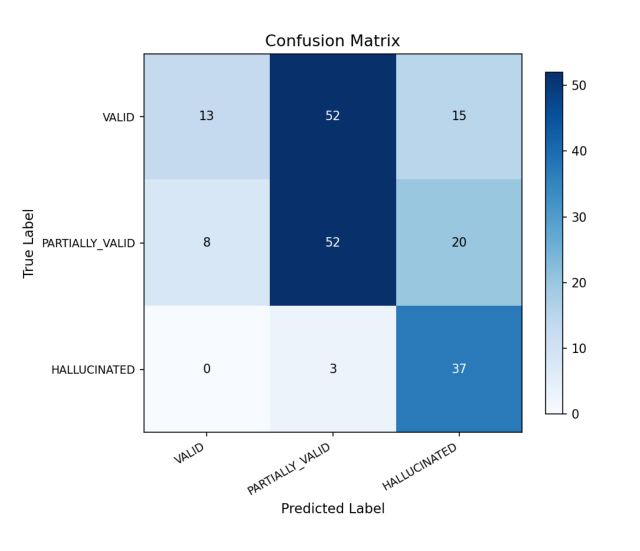

In [4]:
img = mpimg.imread(os.path.join(PLOTS_DIR, 'confusion_matrix.png'))
plt.figure(figsize=(8, 7))
plt.imshow(img)
plt.axis('off')
plt.show()

### Plot 2: Per-Class F1 Score

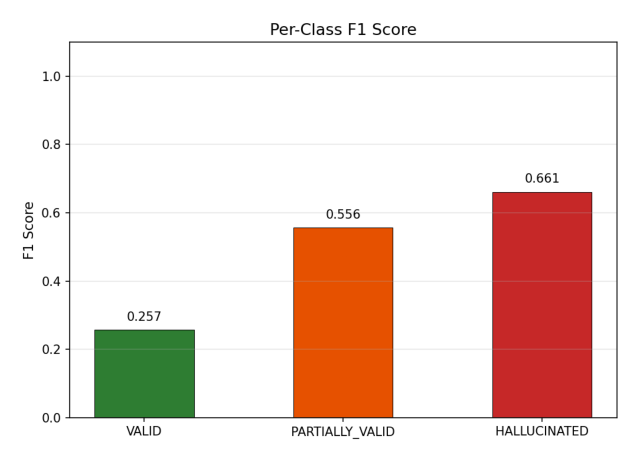

In [5]:
img = mpimg.imread(os.path.join(PLOTS_DIR, 'f1_barchart.png'))
plt.figure(figsize=(8, 6))
plt.imshow(img)
plt.axis('off')
plt.show()

### Plot 3: Confidence Score Distribution

In [4]:
img = mpimg.imread(os.path.join(PLOTS_DIR, 'confidence_distribution.png'))
plt.figure(figsize=(15, 5))
plt.imshow(img)
plt.axis('off')
plt.show()

### Plot 4: Misclassification by Corruption Type

In [5]:
img = mpimg.imread(os.path.join(PLOTS_DIR, 'misclassification_by_corruption.png'))
plt.figure(figsize=(11, 6))
plt.imshow(img)
plt.axis('off')
plt.show()

## Analysis

### What improved

- **PARTIALLY_VALID is now correctly predicted** (F1=0.556, was 0). The middle band is working.
- 52/80 PARTIALLY_VALID citations correctly identified (+52 from previous run).
- **Macro F1 up from 0.388 to 0.491** (+26.7% relative).
- **HALLUCINATED recall still strong** at 92.5% (was 100%, only 3 fake papers leaked through).
- **VALID precision up** from 0.515 to 0.619 — we’re more confident when we say VALID.

### What regressed

- **VALID recall collapsed** from 66.3% to 16.3%. Only 13/80 VALID citations have a DOI+title match or author+year match.
  Most VALID citations (52/80) fall to the heuristic and score in the 0.30–0.70 range → PARTIALLY_VALID.
  15 VALID citations score below 0.30 → HALLUCINATED.
- **3 hallucinated papers** scored above 0.30 due to the higher semantic weight (0.20), producing false PARTIALLY_VALID.

### Trade-off

The stricter exact match reduced VALID promotions (from 50 to 8 PARTIALLY_VALID→VALID).
The new heuristic weights and lower threshold correctly identified many PARTIALLY_VALID citations,
but also pulled many genuine VALID citations into the middle band.

### Next steps to consider
- Lower the VALID threshold (e.g., 0.60) to recapture some VALID citations now in PARTIALLY_VALID.
- Add title+embedded DOI detection for arXiv IDs in citation text.
- Tune the author overlap threshold (currently 0.80) — may be too strict for abbreviated author lists.

## Raw Predictions

In [7]:
df

    citation_id  ...                                               notes
0            27  ...                                                NaN
1            46  ...                                                NaN
..          ...  ...                                                ...
199         107  ...                     Only first two authors listed

[200 rows x 7 columns]

In [6]:
# Misclassified records
mis = df[df['true_label'] != df['predicted_label']]
print(f'Total misclassified: {len(mis)} out of {len(df)}')
mis[['citation_id', 'true_label', 'predicted_label', 'confidence', 'corruption_type']].head(30)

Total misclassified: 98 out of 200
